# Physical hysteresis constraints on simulation data

Choose the hologram source and circular helicity below. This uses the same shared-charge / real-magnetization factorization as `2601_XPCS`, with only original file indices 0 (+1) and 2 (-1) as saturation anchors; all other states are fitted freely. The beamstop opacity becomes a binary exclusion mask (`opacity > 0` by default). Ideal data is actually stored at `holograms/ideal` in this run. No measured-intensity normalization or truth initialization is applied.

These are independent simulated textures, not a magnetic-field sweep: curves use file order. Saved `object_mean_mz` values are used only for comparison after retrieval. Start with a single coherent mode. The support is used on its native centered object grid; detector crop is zero to retain the supplied geometry. The forward simulation includes effects beyond the shared-charge model, so inspect detector residuals and truth agreement. Saturation anchors are calibration, not validation.

Run warmup once, then rerun the physical stage to compare settings. Outputs go into this folder's `processed/` directory.


In [26]:
from pathlib import Path
import sys, json
from copy import deepcopy
import numpy as np
import h5py
import matplotlib.pyplot as plt
HERE = Path.cwd()
if HERE.name != 'simulation_hysteresis': HERE = HERE / 'simulation_hysteresis'
sys.path.insert(0, str(HERE.parent))
# Load this folder's adapter without colliding with other reconstruction_inputs modules.
import importlib.util
spec = importlib.util.spec_from_file_location('simulation_inputs', HERE / 'reconstruction_inputs.py')
inputs = importlib.util.module_from_spec(spec); spec.loader.exec_module(inputs)
from library import phase_retrieval_universal as universal
from library import phase_retrieval_geometry as geometry
DATA_ROOT = inputs.DEFAULT_DATA
HOLOGRAM_SOURCE = 'ideal'# 'detected_no_beamstop'  # or 'ideal' / 'holograms_ideal'
HELICITY = 'CR'  # or 'CL'; one helicity across all states, as in XPCS
FILE_INDICES = None  # None: all 24 files; e.g. [0, 1, 2, 3, 4, 14] for a smaller run
BEAMSTOP_THRESHOLD = 0.  # Exclude any nonzero opacity, including soft edges
MODES = [1]
MODE_2_COMMON = True
WARMUP_ITERATIONS = [120, 60]
OUTER_ITERATIONS = 3
INNER_ITERATIONS = 60
PHYSICAL_ITERATIONS = 5
PROJECTION_RELAXATION = .45
FINAL_PROJECTION_RELAXATION = 0.  # 0: skip final projection; 1: fully enforce fitted model
USE_EXIT_WAVE_INTENSITY_WEIGHTS = True  # False: uniform spatial fit weights
CLIP_MAGNETIZATION = True
BINARY_MAGNETIZATION = False
USE_PARTIAL_COHERENCE = False
FOCUS_PROP_UM = 0.
FOCUS_PHASE_RAD = 0.
OBSERVATION_WORKERS = 1
FFT_WORKERS = 1
CHEMICAL_SPECIES = None
CHEMICAL_REFERENCE_MASK = None
OUTPUT = HERE / 'processed' / f'physical_{HOLOGRAM_SOURCE}_{HELICITY}.h5'


In [27]:
data['mask_pixel']

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
data = inputs.load_dataset(DATA_ROOT, HOLOGRAM_SOURCE, HELICITY, FILE_INDICES, BEAMSTOP_THRESHOLD)
holograms, mask_pixel, support = [data[k] for k in ('holograms', 'mask_pixel', 'support')]
import scipy
mask_pixel=mask_pixel*0
support=scipy.ndimage.binary_dilation(support, iterations=4)
data['support']=support.copy()
data['mask_pixel']=mask_pixel.copy()

state_labels, saturated = data['state_labels'], data['saturated']
ENERGY_EV, SETUP = data['energy_ev'], data['setup']
material = universal.largest_support_component(support).astype(bool)
calibrated = set(saturated.values()) == {-1., 1.}
if not calibrated: raise ValueError('Select reference file indices 0 (+1) and 2 (-1)')
print('Grid:', support.shape, 'states:', len(state_labels), 'anchors:', saturated)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.log1p(holograms[0])); axes[0].set_title('First hologram: log(1+I)')
axes[1].imshow(mask_pixel[0]); axes[1].set_title('Binary exclusion mask')
axes[2].imshow(support.astype(int) + material); axes[2].set_title('Support and material aperture')
plt.show()


Support components on the centered object grid (row, column):
  198 pixels; centroid (np.float64(358.010101010101), np.float64(358.04040404040404)); bounds rows 350:367, columns 350:367
  14618 pixels; centroid (np.float64(512.0064304282391), np.float64(512.0194965111507)); bounds rows 443:581, columns 443:582
  81 pixels; centroid (np.float64(666.0), np.float64(358.0)); bounds rows 661:672, columns 353:364


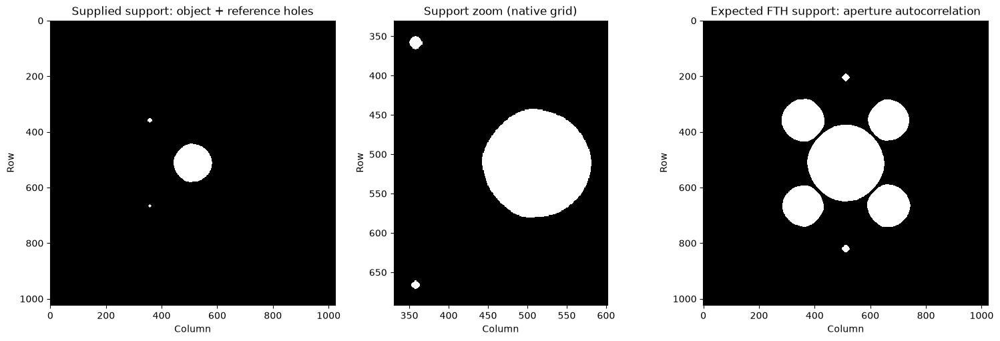

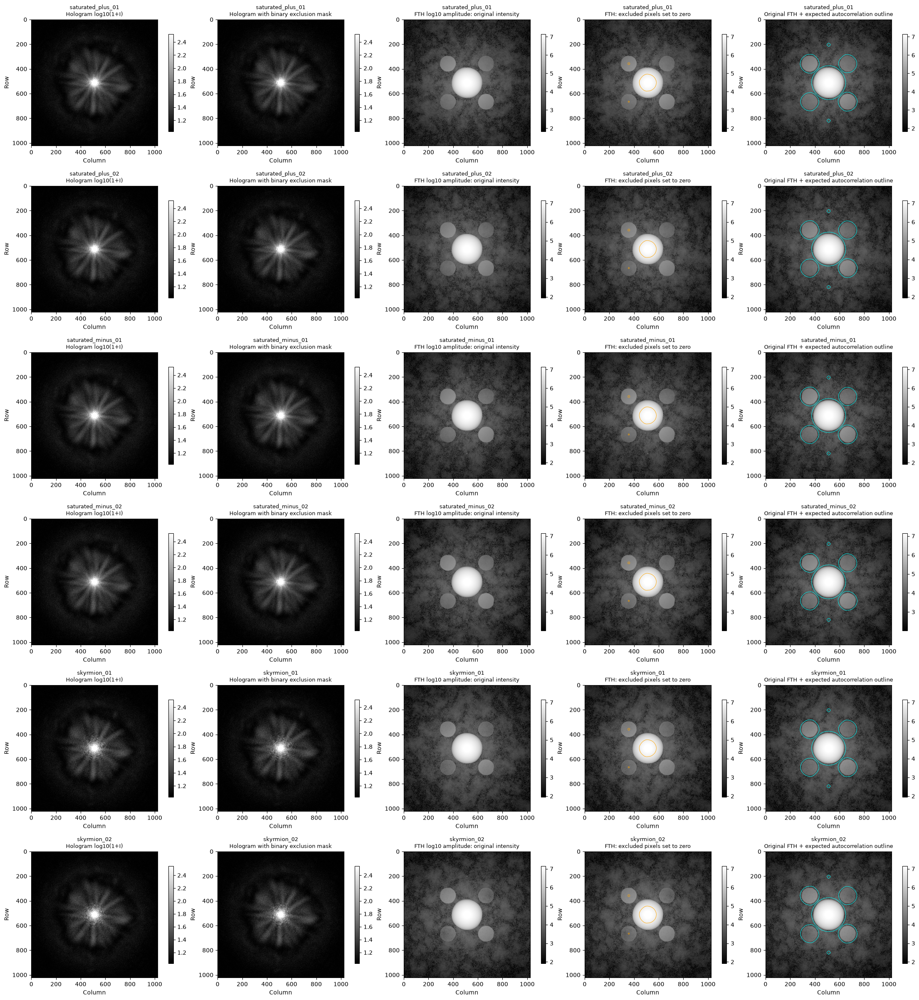

Orange: supplied support (FTH panel) or excluded pixels (hologram panel). Cyan: support autocorrelation.
FTH is the autocorrelation of the exit wave: displaced object images do not lie in the exit-wave support.
Masking introduces Fourier ringing; compare original and masked FTH before judging the support.


In [21]:
# Input diagnostics: run before warmup; positions refer to the loaded stack.
# None displays the two anchors plus four free states. Use e.g. [0, 4, 14]
# with all files loaded to inspect a saturation, skyrmion, and labyrinth.
DIAGNOSTIC_POSITIONS = None
input_diagnostics = inputs.plot_input_diagnostics(data, positions=DIAGNOSTIC_POSITIONS)


In [22]:
recipe=universal.default_universal_phase_retrieval_recipe()
recipe.update(
    # The single-beam, single-energy hysteresis scan is rank-deficient under
    # the general state/energy/beam projector; use the physically constrained
    # charge + magnetization factorization instead.
    projection_model="physical_factorized",
    #projection_model="state_energy_beam",
    modes=MODES,
    # Move enlarged higher-mode supports inside the retrieval field of view.
    recenter_modal_supports=True, mode_support_center="image",
    mode_initialization="support_fft",
    mode_initialization_seed=0,
    material_thickness=material.astype(float), fit_material_thickness=False,
    physical_projection_object_roi=True, physical_phase_reference=True,
    chemical_species=globals().get('CHEMICAL_SPECIES'),
    chemical_reference_mask=globals().get('CHEMICAL_REFERENCE_MASK'),
    saturated_states=saturated, freeze_saturated_fields=False,
    projection_focus_prop_um=FOCUS_PROP_UM, projection_focus_phase_rad=FOCUS_PHASE_RAD,
    projection_focus_setup=SETUP, energy_values=np.array([ENERGY_EV]),
    constrain_nonphysical_modes_common=MODE_2_COMMON, nonphysical_modes_common_relaxation=1.,
    partial_coherence=USE_PARTIAL_COHERENCE, coherence_kernel_scope="shared",
    shared_coherence_update="pooled" if USE_PARTIAL_COHERENCE else "sequential",
    preserve_warmup_masked_intensity=USE_PARTIAL_COHERENCE,
    observation_workers=OBSERVATION_WORKERS,
    fft_workers=FFT_WORKERS,
    warmup_mode=["HAPRE","ER","HAPRE","ER"] if USE_PARTIAL_COHERENCE else ["HAPRE","ER"],
    warmup_Nit=WARMUP_ITERATIONS*2 if USE_PARTIAL_COHERENCE else WARMUP_ITERATIONS,
    warmup_beta_mode=["arctan","const"]*2 if USE_PARTIAL_COHERENCE else ["arctan","const"],
    warmup_alpha_zero=0.5,
    warmup_TV_freq=10,
    warmup_RL_it=[0,0,50,50] if USE_PARTIAL_COHERENCE else 0,
    warmup_start_from_first=False,
    warmup_reference_observation=next((i for i,s in enumerate(state_labels) if s in saturated), 0), startimage_scale_fit="through_origin",
    inner_mode="ER",
    inner_Nit=INNER_ITERATIONS,
    beta_mode="const", beta_zero=.5,
    average_img=1, alpha_zero=0.5, TV_freq=10,
    RL_it=20 if USE_PARTIAL_COHERENCE else 0,
    RL_freq=20,
    outer_iterations=OUTER_ITERATIONS,
    physical_iterations=PHYSICAL_ITERATIONS,
    physical_spatial_weighting="exit_wave_intensity" if USE_EXIT_WAVE_INTENSITY_WEIGHTS else None,
    clip_magnetization=CLIP_MAGNETIZATION if set(saturated.values()) == {-1.,1.} else False,
    projection_every=len(state_labels), projection_relaxation=PROJECTION_RELAXATION,
    final_projection_relaxation=FINAL_PROJECTION_RELAXATION, final_fourier_constraint=False,
    projection_constraints_inside_support_only=True,zero_magnetization_outside_support=True,
    crop=0,binning=1,roi=None,hologram_intensity_cutoff_vmin=-1,
    shuffle_observations=True,random_seed=0,
    binary_magnetization=BINARY_MAGNETIZATION, binary_magnetization_values = [-1, 1],
    )



In [23]:
# Warmup: run once after changing data, modes, geometry, or warmup settings.
from copy import deepcopy
warmup_recipe = deepcopy(recipe)
warmup_recipe.update(
    outer_iterations=0, projection_model="none",
    final_projection_relaxation=0., final_fourier_constraint=False,
    constrain_nonphysical_modes_common=False,
)
universal.print_universal_workflow(warmup_recipe, state_labels=state_labels)
_, warmup, warmup_components, warmup_bsmasks, warmup_errors = universal.universal_phase_retrieval_algorithm(
    holograms, mask_pixel, support,
    state_labels=state_labels, energy_labels=[ENERGY_EV]*len(state_labels),
    polarization_coefficients=[1.]*len(state_labels),
    illumination_labels=["beam0"]*len(state_labels),
    universal_recipe=warmup_recipe,
    phase_retrieval_kernel=universal.multimode_phase_retrieval_kernel,
)
# Record the exact inputs associated with these fields.
import hashlib

def warmup_input_signature():
    digest = hashlib.sha256()
    for value in (holograms, mask_pixel, support):
        array = np.ascontiguousarray(value)
        digest.update(str((array.shape, array.dtype.str)).encode())
        digest.update(memoryview(array).cast('B'))
    settings = dict(states=list(state_labels), energy=float(ENERGY_EV),
                    modes=recipe['modes'], crop=recipe['crop'],
                    binning=recipe['binning'], roi=recipe['roi'],
                    mode_support_center=recipe['mode_support_center'],
                    recenter_modal_supports=recipe['recenter_modal_supports'])
    digest.update(json.dumps(settings, sort_keys=True, default=str).encode())
    return digest.hexdigest()

warmup_signature = warmup_input_signature()
# Immutable baseline for every physical rerun.
warmup = warmup.copy()
warmup.setflags(write=False)
warmup_state_labels = tuple(state_labels)
warmup_geometry = tuple(recipe[key] for key in ("crop", "binning"))
warmup_modes = tuple(MODES)
print("Modal support shifts (row, column):", warmup_components["mode_support_shifts"])
print("Warmup cached. Rerun the physical-stage cell to change only the physical stage.")


Universal phase-retrieval workflow
├─ Geometry: crop 0 pixels, then bin ×1
├─ Reference hologram: 'saturated_plus_01'
│  ├─ start: FFT(support), scaled to measured intensity
│  ├─ HAPRE × 120, support weight 0.5 (const), TV every 10
│  └─ ER × 60, support weight 0.5 (const), TV every 10
├─ Other holograms: 23 observations ('saturated_plus_02' … 'labyrinth_10')
│  ├─ start: FFT(support), scaled to measured intensity
│  ├─ HAPRE × 120, support weight 0.5 (const), TV every 10
│  └─ ER × 60, support weight 0.5 (const), TV every 10
├─ Joint reconstruction × 0 outer loops
│  ├─ observation order: shuffled each loop
│  ├─ each hologram: ER × 60, support weight 0.5 (const), TV every 10
│  └─ none projection every 24 observation updates; relaxation=0.45
├─ Modes: [1]; physical constraints act on support-factor-1 mode
├─ Gamma: each state passes its updated gamma to the next state (serial)
├─ CPU workers: 1; FFT threads each: 1
├─ Final physical projection: skipped (relaxation=0)
├─ Final measur

In [24]:
# Physical stage: edit settings here and rerun without repeating warmup.
if "warmup" not in globals():
    raise RuntimeError("Run the warmup cell first.")
if tuple(state_labels) != warmup_state_labels or tuple(MODES) != warmup_modes:
    raise RuntimeError("States or modes changed: rerun warmup first.")
if tuple(recipe[key] for key in ("crop", "binning")) != warmup_geometry:
    raise RuntimeError("Geometry changed: rerun warmup first.")
if warmup_input_signature() != warmup_signature:
    raise RuntimeError("Input data, support, energy, or geometry changed: rerun warmup first.")
recipe.update(
    outer_iterations=OUTER_ITERATIONS,
    inner_Nit=INNER_ITERATIONS,
    physical_iterations=PHYSICAL_ITERATIONS,
    physical_spatial_weighting="exit_wave_intensity" if USE_EXIT_WAVE_INTENSITY_WEIGHTS else None,
    projection_relaxation=PROJECTION_RELAXATION,
    clip_magnetization=CLIP_MAGNETIZATION if calibrated else False,
    constrain_nonphysical_modes_common=MODE_2_COMMON,
    # Change these here when comparing physical constraints.
    binary_magnetization=BINARY_MAGNETIZATION,
    binary_magnetization_values=[-1, 1],
    final_projection_relaxation=FINAL_PROJECTION_RELAXATION,
)
physical_recipe = deepcopy(recipe)
physical_recipe.update(
    warmup_Nit=0,
    warmup_reference_mode=None, warmup_reference_Nit=None,
    warmup_other_mode=None, warmup_other_Nit=None,
    preserve_warmup_masked_intensity=False,
)
# The API expects starting fields on the source detector grid before cropping.
# Expand binned pixels and embed the warmup in that grid; geometry.prepare
# then recovers the exact cached retrieval fields without a second crop.
crop, binning = warmup_geometry
source_shape = holograms.shape[-2:]
expanded = (warmup if binning == 1 else
            np.repeat(np.repeat(warmup, binning, axis=-2), binning, axis=-1))
origin = tuple(crop + (n - 2*crop - u)//2
               for n, u in zip(source_shape, expanded.shape[-2:]))
starts = np.zeros((*warmup.shape[:-2], *source_shape), dtype=warmup.dtype)
starts[..., origin[0]:origin[0]+expanded.shape[-2],
       origin[1]:origin[1]+expanded.shape[-1]] = expanded
# Verify the source-grid embedding is exactly reversed by preprocessing.
_, _, _, recovered_starts, _ = geometry.prepare(
    holograms, mask_pixel, support, dict(physical_recipe, Nmodes=1), starts)
for cached, recovered in zip(warmup, recovered_starts):
    np.testing.assert_allclose(recovered, cached, rtol=1e-14, atol=0.)
del recovered_starts, expanded
universal.print_universal_workflow(physical_recipe, state_labels=state_labels,
                                 start_fields_provided=True)
fields, physical_start_fields, components, bsmasks, errors = universal.universal_phase_retrieval_algorithm(
    holograms, mask_pixel, support,
    state_labels=state_labels, energy_labels=[ENERGY_EV]*len(state_labels),
    polarization_coefficients=[1.]*len(state_labels),
    illumination_labels=["beam0"]*len(state_labels),
    universal_recipe=physical_recipe, start_fields=starts,
    phase_retrieval_kernel=universal.multimode_phase_retrieval_kernel,
)
del starts
for cached, received in zip(warmup, physical_start_fields):
    np.testing.assert_allclose(received, cached, rtol=1e-14, atol=0.)
del physical_start_fields
if fields.shape != warmup.shape:
    raise RuntimeError("Physical output and cached warmup grids differ.")
errors["cached_warmup_errors"] = deepcopy(warmup_errors)
if "magnetization" not in components:
    raise RuntimeError("No physical fit was performed. Enable outer projections or a final projection.")
if list(components['state_names'])!=state_labels: raise RuntimeError("Unexpected state ordering")
print("Model log-fit residual:",components['fit_residual_rms'])
if components.get('chemical_species_model'):
    print("Chemical species:", components['species_names'])
    print("Chemical spectral contrast rank:", components['chemical_spectral_contrast_rank'])
    print("Vacuum reference pixels:", components['chemical_reference_pixels'])
    for note in components['ambiguity_notes']: print(note)
print("Final physical projection relaxation:", recipe["final_projection_relaxation"])
if len(MODES) > 1:
    print("Mode 2 is " + ("common across states." if MODE_2_COMMON else "independent per state."))


Universal phase-retrieval workflow
├─ Geometry: crop 0 pixels, then bin ×1
├─ Reference hologram: 'saturated_plus_01'
│  ├─ start: supplied start_fields
│  └─ warmup disabled
├─ Other holograms: 23 observations ('saturated_plus_02' … 'labyrinth_10')
│  ├─ start: supplied start_fields
│  └─ warmup disabled
├─ Joint reconstruction × 3 outer loops
│  ├─ observation order: shuffled each loop
│  ├─ each hologram: ER × 60, support weight 0.5 (const), TV every 10
│  └─ physical_factorized projection every 24 observation updates; relaxation=0.45
├─ Modes: [1]; physical constraints act on support-factor-1 mode
├─ Gamma: each state passes its updated gamma to the next state (serial)
├─ CPU workers: 1; FFT threads each: 1
├─ Final physical projection: relaxation=1.0
├─ Final measured-amplitude projection: disabled
└─ Results
   ├─ warmup_fields: fields before joint physical iterations
   ├─ fields: final retrieved fields
   ├─ components: fitted physical/coherence/mode quantities
   ├─ bsmasks: d

In [ ]:
# Spatial fit weights: recalculated at each physical projection from reference exit waves.
fit_weights = np.fft.fftshift(components['physical_spatial_weights'])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.ma.array(fit_weights, mask=~material), cmap='magma')
ax.set_title('Physical fit weights: mean reference exit-wave intensity')
fig.colorbar(im, ax=ax, label='Weight (mean inside object hole = 1)')
plt.show()
print('Weighted physical log-fit RMS:', components['weighted_fit_residual_rms'])


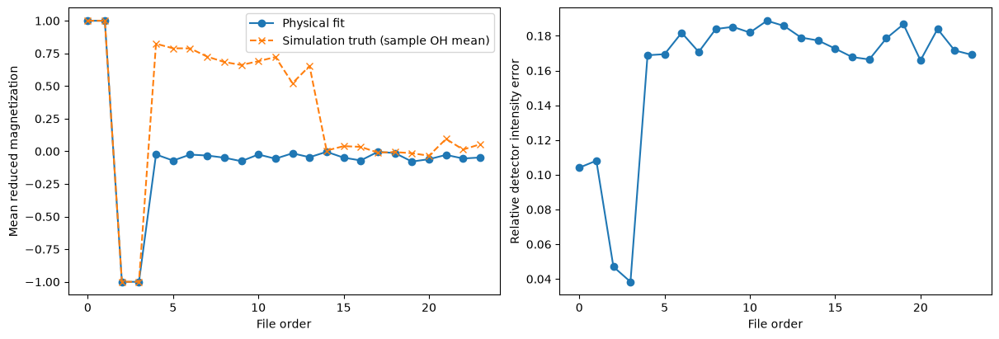

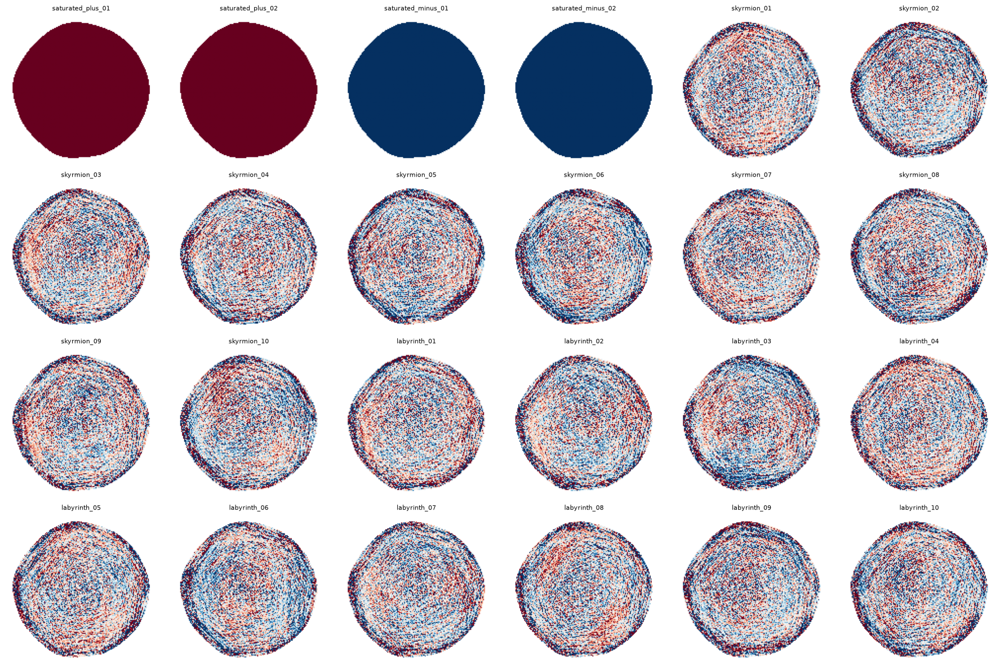

Interior mean-magnetization RMS: 0.5349940954208137
Truth and fit means use their respective sample and retrieval aperture grids.


In [25]:
# Compare model magnetization with saved scalar truth, never used in fitting.
magnetization = np.fft.fftshift(components['magnetization'], axes=(-2, -1))
material_used = np.fft.fftshift(components['material_thickness']) > 0
fit_mean = magnetization[:, material_used].mean(axis=1)
primary = fields if fields.ndim == 3 else fields[:, 0]
final_objects = np.stack([universal.fourier_field_to_display_object(f) for f in primary])
prediction = np.sum(abs(fields)**2, axis=1) if fields.ndim == 4 else abs(fields)**2
valid = ~np.broadcast_to(np.asarray(bsmasks, bool), holograms.shape)
relative_error = np.array([np.linalg.norm((p-h)[v])/np.linalg.norm(h[v])
                           for p,h,v in zip(prediction,holograms,valid)])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
axes[0].plot(fit_mean, 'o-', label='Physical fit target (before relaxation)')
axes[0].plot(data['truth_mean_mz'], 'x--', label='Simulation truth (sample OH mean)')
axes[0].set(xlabel='File order', ylabel='Mean reduced magnetization'); axes[0].legend()
axes[1].plot(relative_error, 'o-'); axes[1].set(xlabel='File order', ylabel='Relative detector intensity error')
plt.show()
roi = geometry.support_bounding_roi(material_used, padding_fraction=.05)
ncols = 6; nrows = int(np.ceil(len(state_labels)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3*nrows), squeeze=False)
for ax in axes.flat: ax.axis('off')
for i, (ax, label) in enumerate(zip(axes.flat, state_labels)):
    im=ax.imshow(np.ma.array(magnetization[i], mask=~material_used)[roi], cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(label, fontsize=8)
plt.tight_layout(); plt.show()
interior = np.array([s not in saturated for s in state_labels])
print('Interior mean-magnetization RMS:', np.sqrt(np.mean((fit_mean[interior]-data['truth_mean_mz'][interior])**2)))
print('Truth and fit means use their respective sample and retrieval aperture grids.')

print('These magnetization maps describe the fitted target; exit waves include projection relaxation.')
print('Joint relaxation:', physical_recipe['projection_relaxation'], '; final relaxation:', physical_recipe['final_projection_relaxation'])


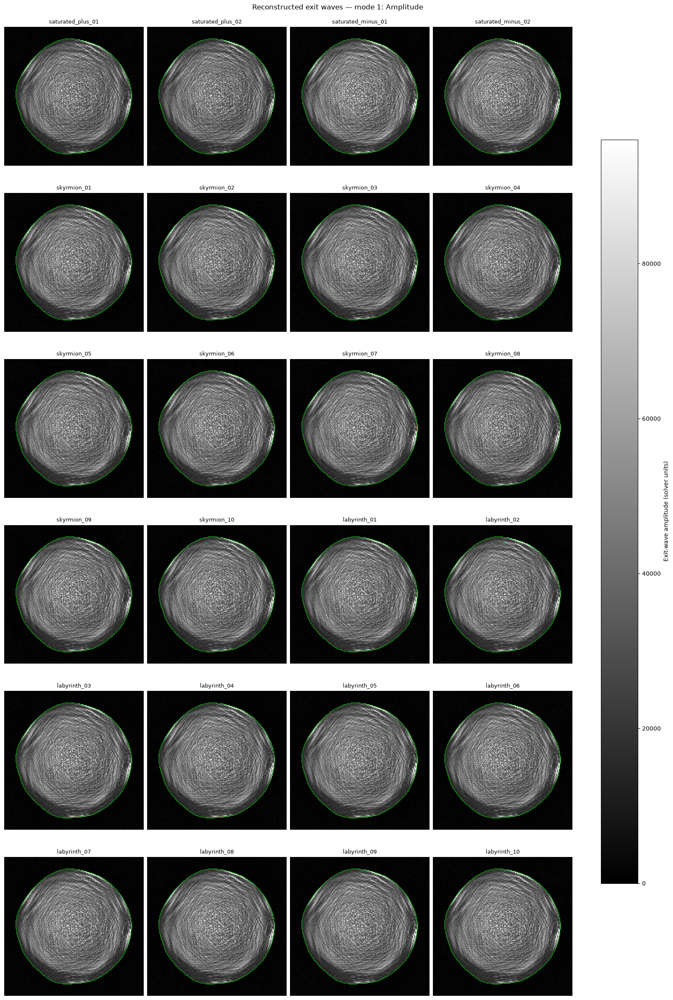

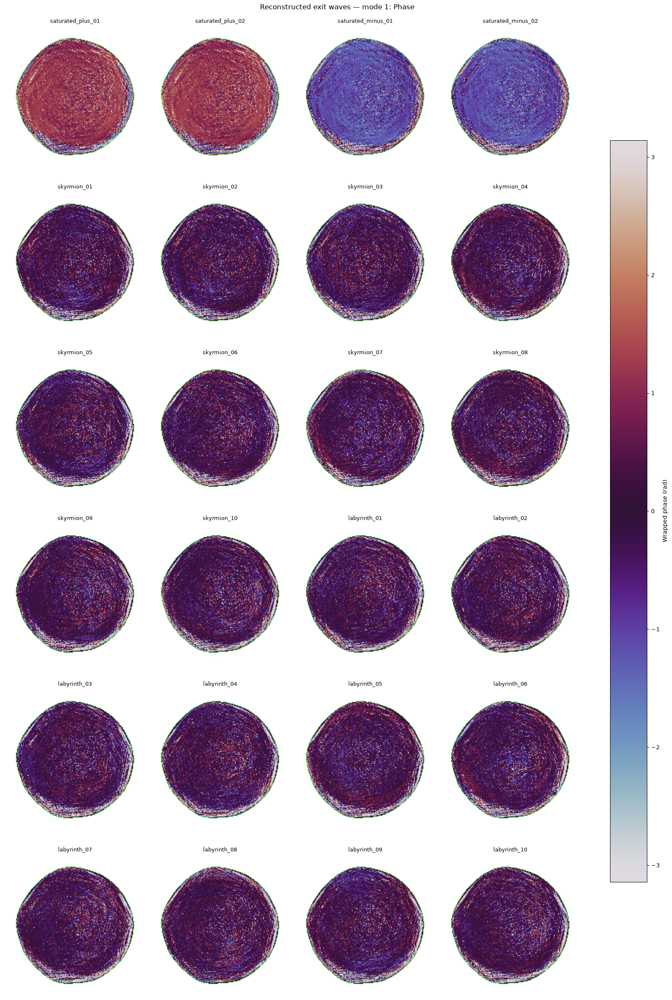

Plots show the returned exit waves before any optional diagnostic focus propagation.
Support outlines include object and reference holes. Global phase remains a reconstruction convention.


In [16]:
# Reconstructed exit waves: amplitude and wrapped phase, including reference holes.
# None displays every state. These are loaded stack positions, not file indices.
EXIT_WAVE_POSITIONS = None
EXIT_WAVE_MODE = 0  # Primary physical mode; choose 1 for mode 2 if enabled.
EXIT_WAVE_COLUMNS = 4

modal_fields = fields[:, None] if fields.ndim == 3 else fields
if not 0 <= EXIT_WAVE_MODE < modal_fields.shape[1]:
    raise ValueError('EXIT_WAVE_MODE must select a reconstructed mode')
positions = list(range(len(state_labels))) if EXIT_WAVE_POSITIONS is None else list(EXIT_WAVE_POSITIONS)
if not positions or any(i < 0 or i >= len(state_labels) for i in positions):
    raise ValueError('Choose valid loaded stack positions')
modal_support = np.asarray(components['modal_supportmask_used'])
if modal_support.ndim == 2: modal_support = modal_support[None]
wave_support = modal_support[EXIT_WAVE_MODE].astype(bool)
wave_roi = geometry.support_bounding_roi(wave_support, padding_fraction=.1)
# Convert returned detector fields with the solver's centered object convention.
exit_waves = np.stack([universal.fourier_field_to_display_object(
    modal_fields[i, EXIT_WAVE_MODE]) for i in positions])
# One amplitude scale across all displayed states; phase is always [-pi, pi].
amplitude_max = np.percentile(np.abs(exit_waves[:, wave_support]), 99.5)
ncols = min(EXIT_WAVE_COLUMNS, len(positions))
if ncols < 1: raise ValueError('EXIT_WAVE_COLUMNS must be positive')
nrows = int(np.ceil(len(positions)/ncols))
for quantity in ('Amplitude', 'Phase'):
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows),
                             squeeze=False, layout='constrained')
    for ax in axes.flat: ax.axis('off')
    for ax, obj, i in zip(axes.flat, exit_waves, positions):
        if quantity == 'Amplitude':
            values = np.abs(obj)
            im = ax.imshow(values[wave_roi], cmap='gray', vmin=0, vmax=amplitude_max)
        else:
            # Phase outside support / at negligible amplitude has no useful meaning.
            invalid = ~wave_support | (abs(obj) < max(amplitude_max*1e-6, 1e-30))
            values = np.ma.array(np.angle(obj), mask=invalid)
            im = ax.imshow(values[wave_roi], cmap='twilight', vmin=-np.pi, vmax=np.pi)
        ax.contour(wave_support[wave_roi], levels=[.5], colors=['lime'], linewidths=.6)
        ax.set_title(state_labels[i], fontsize=9)
    fig.colorbar(im, ax=list(axes.flat), shrink=.75,
                 label='Exit-wave amplitude (solver units)' if quantity == 'Amplitude' else 'Wrapped phase (rad)')
    fig.suptitle(f'Reconstructed exit waves — mode {EXIT_WAVE_MODE+1}: {quantity}')
    plt.show()
print('Plots show the returned exit waves before any optional diagnostic focus propagation.')
print('Support outlines include object and reference holes. Global phase remains a reconstruction convention.')


In [ ]:
# Diagnose saturation-copy bias without changing the reconstruction.
# Compare a converged physical refit of the warmup with the returned fields.
# A constant complex response assumes spatially uniform anchor log contrast.
# Local endpoint normalization is diagnostic only; it uses the anchors per pixel.
RUN_SATURATION_AUDIT = True
if RUN_SATURATION_AUDIT:
    print('WARMUP saturation audit')
    warmup_saturation_audit = inputs.audit_saturation_reconstruction(
        warmup, state_labels, saturated, material, energy_ev=ENERGY_EV, iterations=100,
        spatial_weighting="exit_wave_intensity" if USE_EXIT_WAVE_INTENSITY_WEIGHTS else None)
    print('RETURNED FIELDS saturation audit')
    final_saturation_audit = inputs.audit_saturation_reconstruction(
        fields, state_labels, saturated, material, energy_ev=ENERGY_EV, iterations=100,
        spatial_weighting="exit_wave_intensity" if USE_EXIT_WAVE_INTENSITY_WEIGHTS else None)


In [ ]:
def save_tree(group, values):
    for key, value in values.items():
        if isinstance(value, dict): save_tree(group.create_group(str(key)), value)
        elif value is None: group.attrs[str(key)] = 'None'
        else:
            array = np.asarray(value)
            if array.dtype.kind in 'biufc': group.create_dataset(str(key), data=array)
            else: group.attrs[str(key)] = json.dumps(value, default=str)
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
partial = OUTPUT.with_suffix('.partial.h5')
with h5py.File(partial, 'w') as h:
    h.attrs['source_records_json'] = json.dumps(data['records'])
    h.attrs['saturated_states_json'] = json.dumps(saturated)
    h.attrs['recipe_json'] = json.dumps(physical_recipe, default=lambda x: np.asarray(x).tolist())
    h.attrs['beamstop_threshold'] = BEAMSTOP_THRESHOLD
    h.attrs['helicity'] = HELICITY
    h.attrs['energy_ev'] = ENERGY_EV
    h.attrs['magnetization_units'] = 'relative saturation-normalized mz'
    h.create_dataset('state_labels', data=np.asarray(state_labels, dtype=h5py.string_dtype()))
    for name, value in dict(fields=fields, warmup_fields=warmup, magnetization=magnetization,
            supportmask=support, material_mask=material_used, mask_pixel=bsmasks,
            mean_mz=fit_mean, truth_mean_mz=data['truth_mean_mz'], detector_relative_error=relative_error).items():
        h.create_dataset(name, data=value, compression='gzip')
    save_tree(h.create_group('physical_components'), components)
    save_tree(h.create_group('histories'), errors)
partial.replace(OUTPUT)
print('Saved', OUTPUT)
